In [28]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [29]:
df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

In [30]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


Data Preprocessing

In [31]:
df.shape

(2640, 12)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [33]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [34]:
df['Model'].value_counts()

Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64

In [35]:
df['Region'].value_counts()

Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64

# **Exploratory Data Analysis (EDA)**

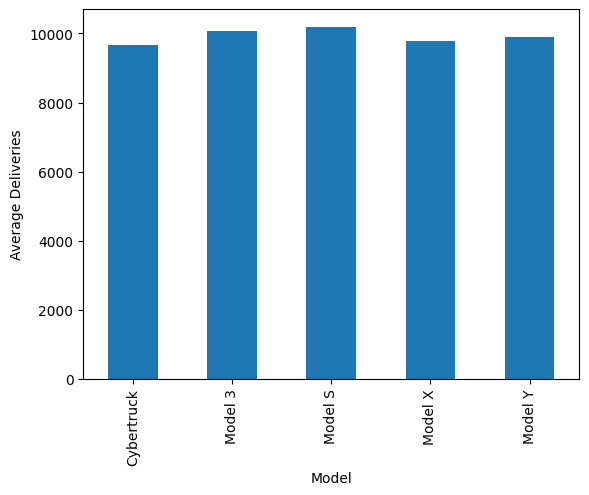

In [36]:
import matplotlib.pyplot as plt

avg_deliveries = df.groupby('Model')['Estimated_Deliveries'].mean()

avg_deliveries.plot(kind='bar')
plt.ylabel('Average Deliveries')
plt.show()

array([[<Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Month'}>,
        <Axes: title={'center': 'Estimated_Deliveries'}>],
       [<Axes: title={'center': 'Production_Units'}>,
        <Axes: title={'center': 'Avg_Price_USD'}>,
        <Axes: title={'center': 'Battery_Capacity_kWh'}>],
       [<Axes: title={'center': 'Range_km'}>,
        <Axes: title={'center': 'CO2_Saved_tons'}>,
        <Axes: title={'center': 'Charging_Stations'}>]], dtype=object)

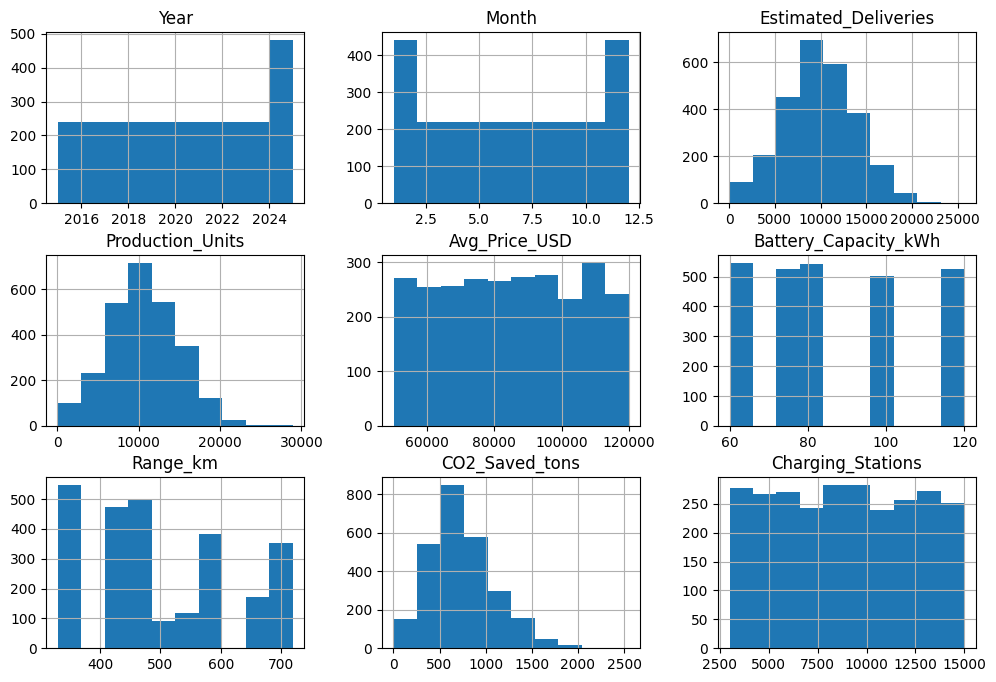

In [37]:
df.hist(figsize=(12,8))

<Axes: ylabel='Estimated_Deliveries'>

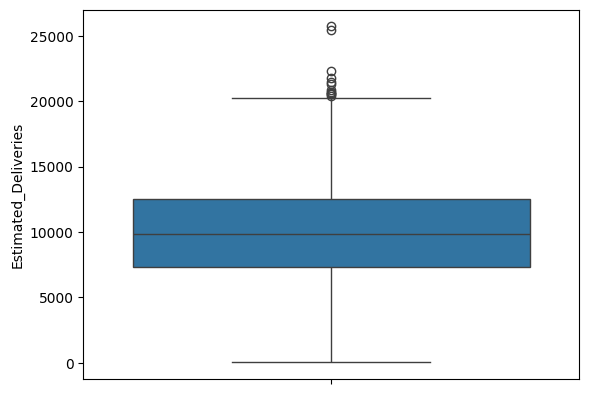

In [38]:
import seaborn as sns
sns.boxplot(df['Estimated_Deliveries'])

<Axes: xlabel='Month'>

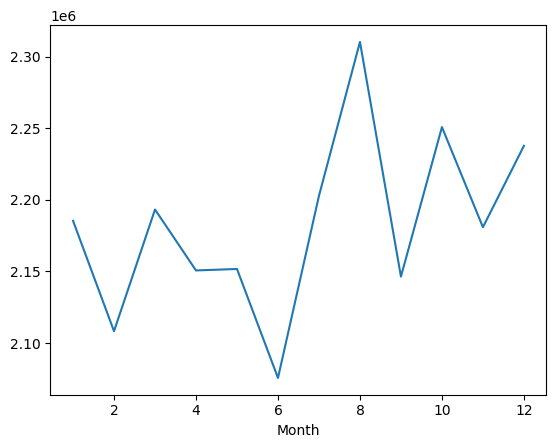

In [39]:
monthly = df.groupby('Month')['Estimated_Deliveries'].sum()
monthly.plot(kind='line')

In [40]:
df.groupby('Year')['Estimated_Deliveries'].sum()


Year
2015    2375267
2016    2434081
2017    2350517
2018    2423104
2019    2404230
2020    2280336
2021    2335116
2022    2434220
2023    2382375
2024    2406899
2025    2368462
Name: Estimated_Deliveries, dtype: int64

In [41]:
df.groupby('Region')['Estimated_Deliveries'].mean()

Region
Asia              9908.992424
Europe            9839.446970
Middle East      10148.553030
North America     9791.806061
Name: Estimated_Deliveries, dtype: float64

In [42]:
df.groupby('Model')['Estimated_Deliveries'].mean()

Model
Cybertruck     9677.611742
Model 3       10079.392045
Model S       10190.123106
Model X        9767.500000
Model Y        9896.371212
Name: Estimated_Deliveries, dtype: float64

In [43]:
df.groupby('Source_Type')['Estimated_Deliveries'].mean()

Source_Type
Estimated (Region)      9977.357798
Interpolated (Month)    9939.804299
Official (Quarter)      9850.185520
Name: Estimated_Deliveries, dtype: float64

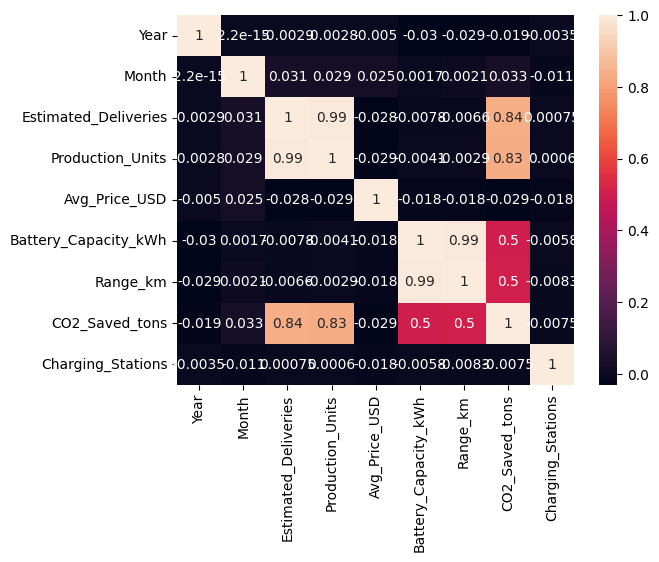

In [44]:
corr = df.corr(numeric_only=True)
plt.plot(figsize=(12,8))
sns.heatmap(corr, annot=True)
plt.show()

<Axes: xlabel='Production_Units', ylabel='Estimated_Deliveries'>

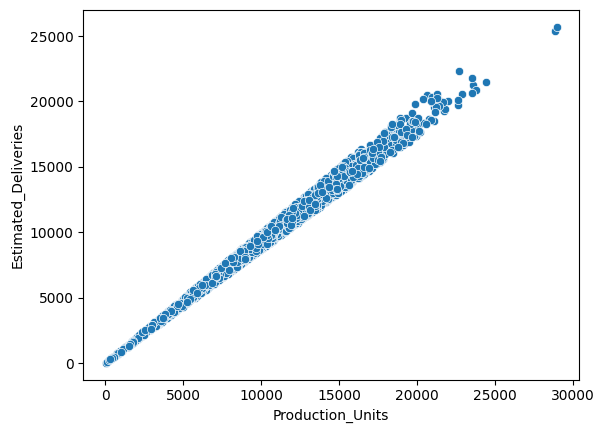

In [45]:
sns.scatterplot(
    x = 'Production_Units',
    y = 'Estimated_Deliveries',
    data = df
)

<Axes: xlabel='Avg_Price_USD', ylabel='Estimated_Deliveries'>

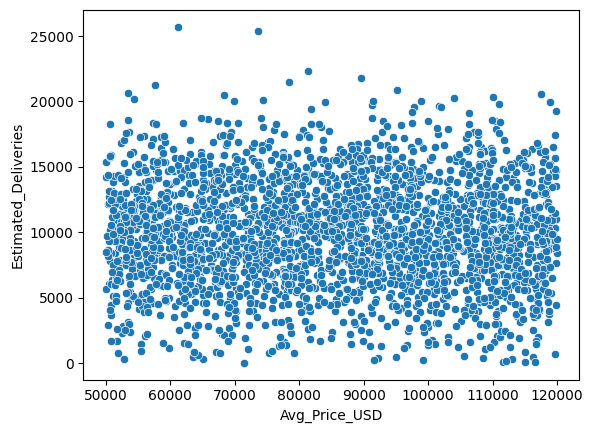

In [46]:
sns.scatterplot(
    x = 'Avg_Price_USD',
    y = 'Estimated_Deliveries',
    data = df
)

<Axes: xlabel='Range_km', ylabel='Estimated_Deliveries'>

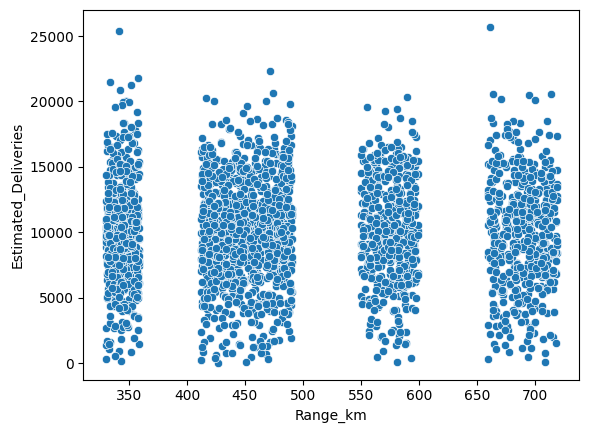

In [47]:
sns.scatterplot(
    x = 'Range_km',
    y = 'Estimated_Deliveries',
    data = df
)

<Axes: xlabel='Battery_Capacity_kWh', ylabel='Range_km'>

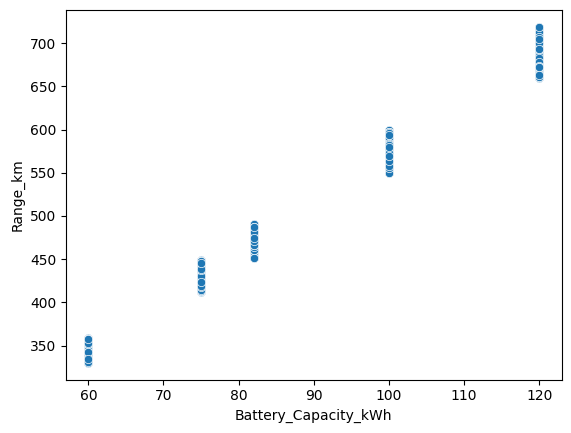

In [48]:
sns.scatterplot(
    x = 'Battery_Capacity_kWh',
    y = 'Range_km',
    data = df
)

<Axes: xlabel='Charging_Stations', ylabel='Estimated_Deliveries'>

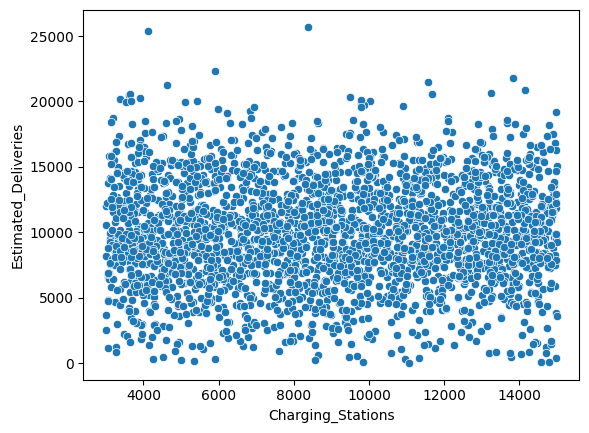

In [49]:
sns.scatterplot(
    x = 'Charging_Stations',
    y = 'Estimated_Deliveries',
    data = df
)

<Axes: xlabel='CO2_Saved_tons', ylabel='Estimated_Deliveries'>

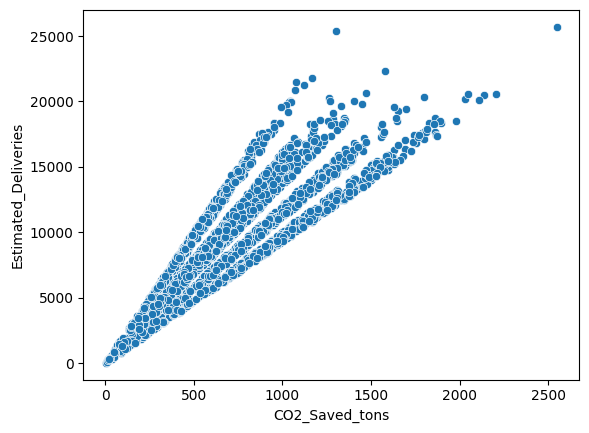

In [50]:
sns.scatterplot(
    x = 'CO2_Saved_tons',
    y = 'Estimated_Deliveries',
    data = df
)

# Encoding

# **Feature Engineering**

In [51]:
df_check = df.copy()

In [52]:
df_check['Value_score'] = df['Range_km'] / df['Avg_Price_USD']
df_check['Value_score']

0       0.007580
1       0.007041
2       0.004072
3       0.007974
4       0.005755
          ...   
2635    0.006320
2636    0.005947
2637    0.005971
2638    0.005115
2639    0.009172
Name: Value_score, Length: 2640, dtype: float64

In [53]:
df_check['range_per_kwh'] = df['Range_km'] / df['Battery_Capacity_kWh']
df_check['range_per_kwh']

0       5.866667
1       5.840000
2       5.853659
3       5.933333
4       5.508333
          ...   
2635    5.991667
2636    5.939024
2637    5.800000
2638    5.966667
2639    5.780488
Name: range_per_kwh, Length: 2640, dtype: float64

# **Encoding Categorical Values**

In [54]:
df_encoded = pd.get_dummies(
    df,
    columns=['Region','Model','Source_Type'],
    drop_first = True
)

In [55]:
X = df_encoded.drop('Estimated_Deliveries',axis=1)
y = df['Estimated_Deliveries']

In [56]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=2)


# **Linear Regression**

In [57]:
df_new = df_encoded.drop('CO2_Saved_tons',axis=1)
X_new = df_new.drop('Estimated_Deliveries',axis=1)
from sklearn.model_selection import train_test_split
X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(X_new, y, test_size = 0.2, random_state=2)

In [58]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerical_cols = ['Year',
    'Month',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'Charging_Stations']
X_new_train[numerical_cols] = scaler.fit_transform(X_new_train[numerical_cols])
X_new_test[numerical_cols] = scaler.transform(X_new_test[numerical_cols])

In [59]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_new_train, y_train)
y_pred = lr.predict(X_new_test)


In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2_score = r2_score(y_test, y_pred)

In [61]:
print("mean_absolute_error:", mae)
print("mean_squared_error:",mse)
print("root_mean_squared_error:",np.sqrt(mse))
print("r2_score:", r2_score)

mean_absolute_error: 355.11161834634174
mean_squared_error: 186543.30496720795
root_mean_squared_error: 431.9065928730516
r2_score: 0.9864727905381698


# **Random Forest**

In [62]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train, y_train)
y_rand_pred = model.predict(X_test)

In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
rand_mae = mean_absolute_error(y_test, y_rand_pred)
rand_mse = mean_squared_error(y_test, y_rand_pred)
r2_rand_score = r2_score(y_test, y_rand_pred)

In [64]:
print("Random Forest mean_absolute_error:", rand_mae)
print("Random Forest mean_squared_error:",rand_mse)
print("Random Forest root_mean_squared_error:",np.sqrt(rand_mse))
print("Random Forest r2_score:", r2_rand_score)

Random Forest mean_absolute_error: 318.09079545454546
Random Forest mean_squared_error: 163598.71756136368
Random Forest root_mean_squared_error: 404.47338300729217
Random Forest r2_score: 0.9881366199632392


# **Hyperparameter Tuning** 

In [65]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

params = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


# **Cross Validation Scores**

In [66]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("CV Scores:", scores)
print("Mean CV R²:", scores.mean())

CV Scores: [0.98892844 0.98981381 0.98759472 0.99008653 0.99069641]
Mean CV R²: 0.9894239828893087


# **Time Series Forecasting**

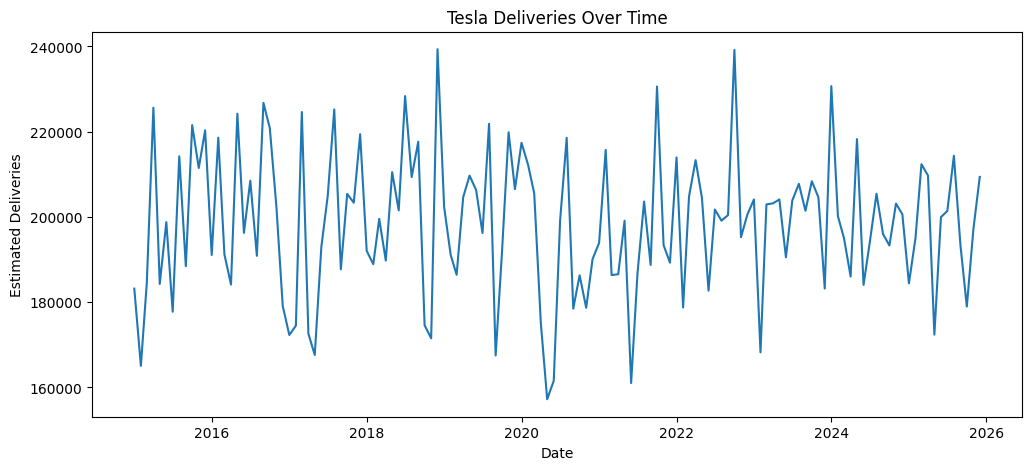

In [67]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str)
    + "-"
    + df["Month"].astype(str)
)

monthly_sales = (
    df.groupby("Date")["Estimated_Deliveries"]
      .sum()
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values
)

plt.title("Tesla Deliveries Over Time")

plt.xlabel("Date")

plt.ylabel("Estimated Deliveries")

plt.show()

In [68]:
import joblib

joblib.dump(model, "tesla_delivery_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully
